# Hypothesis 3
### H₀ (Null Hypothesis): 
### The phishing detection models do not generalise well across different datasets with varying feature distributions.
### H₁ (Alternative Hypothesis): 
### The phishing detection models generalise effectively across different datasets with varying feature distributions.

## Data Preprocesing

In [20]:
import pandas as pd
import numpy as np
import matplotlib
import seaborn
import sklearn
import xgboost
import lightgbm
import tensorflow
import keras
import random
import time
import os

# Print versions
print("Library Versions:")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {seaborn.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"xgboost: {xgboost.__version__}")
print(f"lightgbm: {lightgbm.__version__}")
print(f"tensorflow: {tensorflow.__version__}")
print(f"keras: {keras.__version__}")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

Library Versions:
pandas: 2.2.3
numpy: 1.26.4
matplotlib: 3.9.2
seaborn: 0.13.2
scikit-learn: 1.7.2
xgboost: 2.1.4
lightgbm: 4.6.0
tensorflow: 2.20.0
keras: 3.11.3


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold

In [22]:
df = pd.read_csv("dataset_small.csv") 


In [23]:
df_cleaned = df.copy()

# Check for missing values
print("----------Missing Values Count per Column ----------")
missing_counts = df_cleaned.isnull().sum()
print(missing_counts[missing_counts > 0])  

# If missing values exist, fill them with mean (only for numeric columns)
if missing_counts.sum() > 0:
    df_cleaned.fillna(df_cleaned.mean(numeric_only=True), inplace=True)
    print("\nMissing values have been imputed with mean.")
else:
    print("\nNo missing values found. No imputation needed.")

----------Missing Values Count per Column ----------
Series([], dtype: int64)

No missing values found. No imputation needed.


In [24]:
duplicate_count = df_cleaned.duplicated().sum()
print(f"\n----------Duplicate Check----------\nFound {duplicate_count} duplicate rows.")

if duplicate_count > 0:
    df_cleaned.drop_duplicates(inplace=True)
    print(f"\nDropped {duplicate_count} duplicate rows.\nNew shape: {df_cleaned.shape}")
else:
    print("\nNo duplicate rows found.")


----------Duplicate Check----------
Found 1240 duplicate rows.

Dropped 1240 duplicate rows.
New shape: (57405, 112)


In [25]:
print("----------Single-Valued Columns----------\n")
single_val_cols = []

for col in df_cleaned.columns:
    if df_cleaned[col].nunique() == 1:
        single_val_cols.append(col)

if single_val_cols:
    print(f"Found {len(single_val_cols)} single-valued columns:")
    df_cleaned.drop(columns=single_val_cols, inplace=True)
    for col in single_val_cols:
        print(f"{col}")
    print(f"\nDropped {len(single_val_cols)} columns.")
else:
    print("\nNo single-valued columns found.")

----------Single-Valued Columns----------

Found 13 single-valued columns:
qty_slash_domain
qty_questionmark_domain
qty_equal_domain
qty_and_domain
qty_exclamation_domain
qty_space_domain
qty_tilde_domain
qty_comma_domain
qty_plus_domain
qty_asterisk_domain
qty_hashtag_domain
qty_dollar_domain
qty_percent_domain

Dropped 13 columns.


In [26]:
print("\n----------Dropping Binary Columns with -1----------")

binary_columns_with_minus_one = [
    col for col in df_cleaned.columns
    if sorted(df_cleaned[col].dropna().unique().tolist()) in [[-1, 0], [-1, 1]]
]

if binary_columns_with_minus_one:
    print(f"Found {len(binary_columns_with_minus_one)} binary columns with [-1, 0] or [-1, 1]:")
    for col in binary_columns_with_minus_one:
        print(f"{col}")
    df_cleaned.drop(columns=binary_columns_with_minus_one, inplace=True)
    print(f"\nDropped {len(binary_columns_with_minus_one)} columns.")
else:
    print("No binary (-1, 0) or (-1, 1) columns found.")



----------Dropping Binary Columns with -1----------
Found 7 binary columns with [-1, 0] or [-1, 1]:
qty_questionmark_directory
qty_hashtag_directory
qty_slash_file
qty_questionmark_file
qty_hashtag_file
qty_dollar_file
qty_hashtag_params

Dropped 7 columns.


In [27]:
X = df_cleaned.drop(columns=['phishing']) 
y = df_cleaned['phishing']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [28]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01, random_state=SEED)
mask = iso.fit_predict(X_train) == 1

# Convert to pandas if needed, filter, then reset index
if isinstance(X_train, pd.DataFrame):
	X_train = X_train[mask].reset_index(drop=True)
else:
	X_train = pd.DataFrame(X_train[mask]).reset_index(drop=True)

if isinstance(y_train, pd.Series):
	y_train = y_train[mask].reset_index(drop=True)
else:
	y_train = pd.Series(y_train[mask]).reset_index(drop=True)

print(f"After outlier removal: X_train={X_train.shape}, y_train={y_train.shape}")

After outlier removal: X_train=(45464, 91), y_train=(45464,)


In [29]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_train = pd.DataFrame(selector.fit_transform(X_train), columns=X_train.columns[selector.get_support()])
X_test  = pd.DataFrame(selector.transform(X_test), columns=X_train.columns)

In [30]:
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [col for col in upper.columns if any(upper[col] > 0.8)]

In [31]:
X_train.drop(columns=high_corr_features, inplace=True)
X_test.drop(columns=high_corr_features, inplace=True)

print(f"Removed {len(high_corr_features)} highly correlated features")

Removed 37 highly correlated features


In [32]:
scaler = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns)

In [33]:
# Ensure X_train and y_train have aligned and clean indexes
X_train = X_train.reset_index(drop=True)
y_train = pd.Series(y_train).reset_index(drop=True)

In [34]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, roc_auc_score
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# ---------- INPUT ----------
# X_train: preprocessed feature matrix (shape: [n_samples, 55])
# y_train: binary target vector

# 1. Compute Feature Importance Scores
mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)
mi_scores = pd.Series(mi_selector.scores_, index=X_train.columns)
mi_rank = mi_scores.rank(ascending=False)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_scores = pd.Series(rf.feature_importances_, index=X_train.columns)
rf_rank = rf_scores.rank(ascending=False)

perm = permutation_importance(rf, X_train, y_train, n_repeats=10, random_state=42)
perm_scores = pd.Series(perm.importances_mean, index=X_train.columns)
perm_rank = perm_scores.rank(ascending=False)

# 2. Aggregate rankings (weighted sum)
combined_rank = 0.4 * mi_rank + 0.3 * rf_rank + 0.3 * perm_rank
sorted_features = combined_rank.sort_values().index.tolist()

# 3. Evaluation function (maximize recall, reduce FPR)
def evaluate_feature_subset(feature_list, X, y):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    recalls = []
    fprs = []

    for train_idx, val_idx in skf.split(X, y):
        X_train_cv, X_val_cv = X.iloc[train_idx][feature_list], X.iloc[val_idx][feature_list]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
        model.fit(X_train_cv, y_train_cv)

        y_pred = model.predict(X_val_cv)
        recall = recall_score(y_val_cv, y_pred)

        # Calculate FPR
        tn, fp, fn, tp = confusion_matrix(y_val_cv, y_pred).ravel()
        fpr = fp / (fp + tn) if (fp + tn) != 0 else 0.0

        recalls.append(recall)
        fprs.append(fpr)

    avg_recall = np.mean(recalls)
    avg_fpr = np.mean(fprs)
    score = (0.6 * avg_recall) + (0.4 * (1 - avg_fpr))  # custom weighted score
    return score, avg_recall, avg_fpr

# 4. Grid search top-k
best_k = 0
best_score = 0
best_recall = 0
best_fpr = 1.0

for k in range(10, 40, 5):  # Try top-10 to top-50 features
    top_k_features = sorted_features[:k]
    score, avg_recall, avg_fpr = evaluate_feature_subset(top_k_features, X_train, y_train)

    print(f"Top-{k} | Score: {score:.4f} | Recall: {avg_recall:.4f} | FPR: {avg_fpr:.4f}")

    if score > best_score:
        best_k = k
        best_score = score
        best_recall = avg_recall
        best_fpr = avg_fpr

# 5. Final selected features
final_features = sorted_features[:best_k]
X_train_final = X_train[final_features]
X_test_final = X_test[final_features]

# 6. Output
print(f"\nSelected Top-{best_k} Features (Score = {best_score:.4f}, Recall = {best_recall:.4f}, FPR = {best_fpr:.4f}):")
for i, feat in enumerate(final_features, 1):
    print(f"{i}. {feat}")

Top-10 | Score: 0.9496 | Recall: 0.9564 | FPR: 0.0605
Top-15 | Score: 0.9514 | Recall: 0.9580 | FPR: 0.0585
Top-20 | Score: 0.9536 | Recall: 0.9590 | FPR: 0.0546
Top-25 | Score: 0.9556 | Recall: 0.9614 | FPR: 0.0532
Top-30 | Score: 0.9563 | Recall: 0.9627 | FPR: 0.0532
Top-35 | Score: 0.9551 | Recall: 0.9612 | FPR: 0.0540

Selected Top-30 Features (Score = 0.9563, Recall = 0.9627, FPR = 0.0532):
1. directory_length
2. length_url
3. qty_slash_url
4. time_domain_activation
5. file_length
6. ttl_hostname
7. asn_ip
8. qty_dot_directory
9. qty_hyphen_directory
10. qty_dot_domain
11. time_domain_expiration
12. qty_underline_directory
13. qty_hyphen_file
14. qty_equal_directory
15. time_response
16. qty_vowels_domain
17. qty_dot_url
18. qty_ip_resolved
19. qty_hyphen_url
20. qty_nameservers
21. qty_mx_servers
22. params_length
23. qty_redirects
24. qty_slash_params
25. domain_spf
26. qty_percent_params
27. qty_dot_params
28. tls_ssl_certificate
29. qty_hyphen_params
30. qty_questionmark_param

Text(0.5, 1.0, 'Feature Importance Comparison')

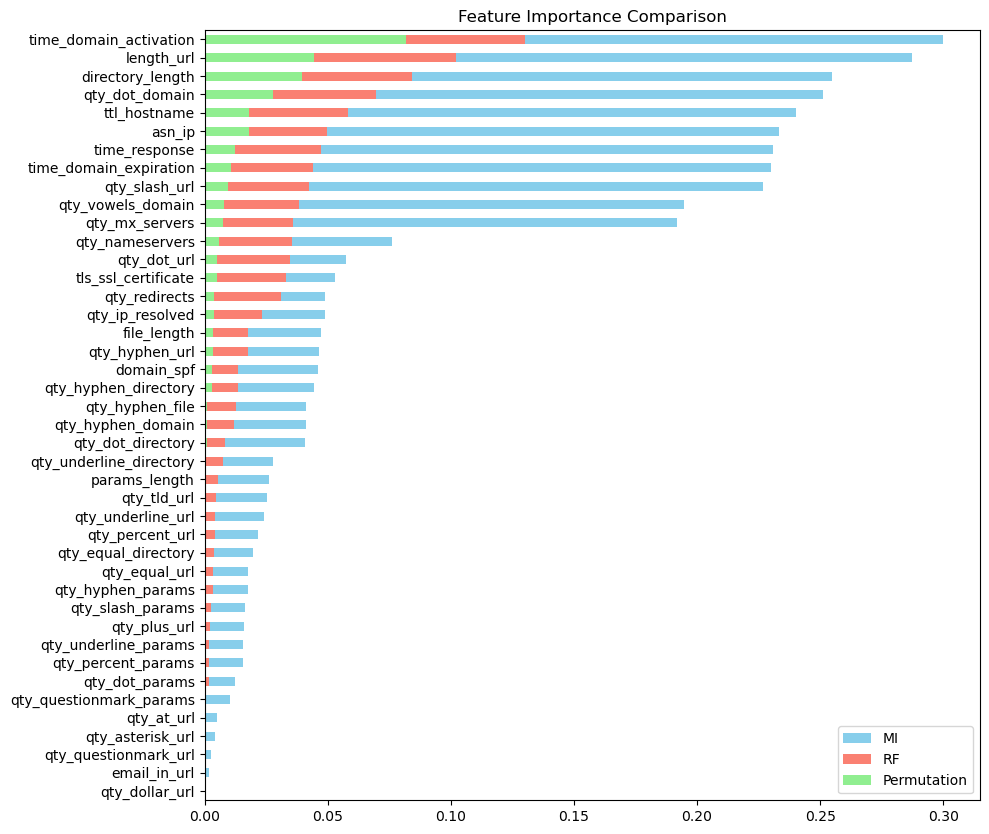

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
mi_scores.sort_values().plot(kind='barh', color='skyblue', label='MI')
rf_scores.sort_values().plot(kind='barh', color='salmon', label='RF')
perm_scores.sort_values().plot(kind='barh', color='lightgreen', label='Permutation')
plt.legend()
plt.title("Feature Importance Comparison")

## Random Forest

In [21]:
X_train_final = X_train_final.to_numpy()
y_train = y_train.to_numpy().ravel()

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, make_scorer
import numpy as np

# ---------------------------
# False Positive Rate Function
# ---------------------------
def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn)

fpr_scorer = make_scorer(false_positive_rate, greater_is_better=False)

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
np.random.seed(SEED)

# ============================================================
# FINAL BEST RANDOM FOREST MODEL
# ============================================================
best_rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=40,
    max_features=0.3,
    min_samples_leaf=1,
    min_samples_split=2,
    bootstrap=False,
    random_state=SEED,
    n_jobs=-1
)

# ============================================================
# 10-FOLD CROSS-VALIDATION
# ============================================================
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

cv_results = cross_validate(
    best_rf,
    X_train_final,
    y_train,
    cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc',
        'fpr': fpr_scorer
    },
    return_train_score=False,
    n_jobs=-1
)

# ============================================================
# PRINT PER-FOLD RESULTS
# ============================================================
print("\n========== PER-FOLD RESULTS ==========\n")

for i in range(10):
    print(f"Fold {i+1}:")
    print(f"  Accuracy : {cv_results['test_accuracy'][i]:.4f}")
    print(f"  Precision: {cv_results['test_precision'][i]:.4f}")
    print(f"  Recall   : {cv_results['test_recall'][i]:.4f}")
    print(f"  F1-score : {cv_results['test_f1'][i]:.4f}")
    print(f"  FPR      : {cv_results['test_fpr'][i]:.4f}")
    print(f"  AUC-ROC  : {cv_results['test_roc_auc'][i]:.4f}")
    print("--------------------------------------")

# ============================================================
# PRINT SUMMARY STATISTICS
# ============================================================
print("\n========== 10-FOLD CROSS-VALIDATION SUMMARY ==========")
print(f"Accuracy    : {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"Precision   : {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"Recall (TPR): {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
print(f"F1-score    : {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")
print(f"FPR         : {cv_results['test_fpr'].mean():.4f} ± {cv_results['test_fpr'].std():.4f}")
print(f"AUC-ROC     : {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")



========== PER-FOLD RESULTS ==========

Fold 1:
  Accuracy : 0.9534
  Precision: 0.9486
  Recall   : 0.9637
  F1-score : 0.9561
  FPR      : -0.0581
  AUC-ROC  : 0.9897
--------------------------------------
Fold 2:
  Accuracy : 0.9562
  Precision: 0.9548
  Recall   : 0.9624
  F1-score : 0.9586
  FPR      : -0.0507
  AUC-ROC  : 0.9906
--------------------------------------
Fold 3:
  Accuracy : 0.9584
  Precision: 0.9619
  Recall   : 0.9591
  F1-score : 0.9605
  FPR      : -0.0423
  AUC-ROC  : 0.9916
--------------------------------------
Fold 4:
  Accuracy : 0.9556
  Precision: 0.9537
  Recall   : 0.9624
  F1-score : 0.9580
  FPR      : -0.0520
  AUC-ROC  : 0.9907
--------------------------------------
Fold 5:
  Accuracy : 0.9536
  Precision: 0.9546
  Recall   : 0.9574
  F1-score : 0.9560
  FPR      : -0.0507
  AUC-ROC  : 0.9902
--------------------------------------
Fold 6:
  Accuracy : 0.9560
  Precision: 0.9511
  Recall   : 0.9662
  F1-score : 0.9586
  FPR      : -0.0553
  AUC-ROC 

## XGBoost

In [22]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, make_scorer
)

# ============================================================
# Custom FPR Function
# ============================================================
def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn)

fpr_scorer = make_scorer(false_positive_rate, greater_is_better=False)

# ============================================================
# Reproducibility
# ============================================================
SEED = 42
np.random.seed(SEED)

# ============================================================
# FINAL BEST XGBOOST MODEL (YOUR BEST PARAMS)
# ============================================================
best_xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    min_child_weight=1,
    reg_alpha=0,
    reg_lambda=1,
    random_state=SEED,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False,
    tree_method='hist'
)

# ============================================================
# 10-FOLD CROSS-VALIDATION SETUP
# ============================================================
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

# ============================================================
# Per-fold results
# ============================================================
acc_list, prec_list, rec_list = [], [], []
f1_list, fpr_list, auc_list = [], [], []

print("\n========== PER-FOLD RESULTS (XGBoost) ==========\n")

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train_final, y_train), 1):
    X_tr, X_val = X_train_final[tr_idx], X_train_final[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    model = XGBClassifier(
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0,
        min_child_weight=1,
        reg_alpha=0,
        reg_lambda=1,
        random_state=SEED,
        n_jobs=-1,
        eval_metric='logloss',
        use_label_encoder=False,
        tree_method='hist'
    )

    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    acc_list.append(accuracy_score(y_val, y_pred))
    prec_list.append(precision_score(y_val, y_pred))
    rec_list.append(recall_score(y_val, y_pred))
    f1_list.append(f1_score(y_val, y_pred))
    auc_list.append(roc_auc_score(y_val, y_proba))
    fpr_list.append(fp / (fp + tn))

    print(f"Fold {fold}:")
    print(f"  Accuracy : {acc_list[-1]:.4f}")
    print(f"  Precision: {prec_list[-1]:.4f}")
    print(f"  Recall   : {rec_list[-1]:.4f}")
    print(f"  F1-score : {f1_list[-1]:.4f}")
    print(f"  FPR      : {fpr_list[-1]:.4f}")
    print(f"  AUC-ROC  : {auc_list[-1]:.4f}")
    print("--------------------------------------")

# ============================================================
# Summary Statistics
# ============================================================
print("\n========== 10-FOLD CROSS-VALIDATION SUMMARY (XGBoost) ==========")
print(f"Accuracy    : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"Precision   : {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
print(f"Recall      : {np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}")
print(f"F1-score    : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"FPR         : {np.mean(fpr_list):.4f} ± {np.std(fpr_list):.4f}")
print(f"AUC-ROC     : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")



========== PER-FOLD RESULTS (XGBoost) ==========



c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:38:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 1:
  Accuracy : 0.9617
  Precision: 0.9637
  Recall   : 0.9637
  F1-score : 0.9637
  FPR      : 0.0404
  AUC-ROC  : 0.9919
--------------------------------------


c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:38:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 2:
  Accuracy : 0.9602
  Precision: 0.9643
  Recall   : 0.9599
  F1-score : 0.9621
  FPR      : 0.0395
  AUC-ROC  : 0.9907
--------------------------------------


...

Fold 8:
  Accuracy : 0.9575
  Precision: 0.9576
  Recall   : 0.9620
  F1-score : 0.9598
  FPR      : 0.0474
  AUC-ROC  : 0.9912
--------------------------------------


c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:38:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 9:
  Accuracy : 0.9597
  Precision: 0.9585
  Recall   : 0.9653
  F1-score : 0.9619
  FPR      : 0.0465
  AUC-ROC  : 0.9924
--------------------------------------


c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:38:54] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 10:
  Accuracy : 0.9580
  Precision: 0.9546
  Recall   : 0.9662
  F1-score : 0.9603
  FPR      : 0.0511
  AUC-ROC  : 0.9927
--------------------------------------

========== 10-FOLD CROSS-VALIDATION SUMMARY (XGBoost) ==========
Accuracy    : 0.9593 ± 0.0015
Precision   : 0.9602 ± 0.0031
Recall      : 0.9627 ± 0.0035
F1-score    : 0.9614 ± 0.0015
FPR         : 0.0444 ± 0.0037
AUC-ROC     : 0.9918 ± 0.0006


## CNN

In [38]:
import os, random, time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Input, Model, backend as K
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from tqdm import tqdm

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

for g in tf.config.list_physical_devices('GPU'):
    try: tf.config.experimental.set_memory_growth(g, True)
    except: pass

X_train_scaled = np.asarray(X_train_final.values if hasattr(X_train_final, "values") else X_train_final, dtype=np.float32)
X_test_scaled  = np.asarray(X_test_final.values  if hasattr(X_test_final, "values") else X_test_final, dtype=np.float32)
y_train_array  = np.asarray(y_train.values if hasattr(y_train, "values") else y_train, dtype=np.int32)
y_test_array   = np.asarray(y_test.values  if hasattr(y_test, "values") else y_test, dtype=np.int32)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

input_dim = int(X_train_scaled.shape[1])

X_train_cnn = X_train_scaled.reshape(-1, input_dim, 1)
X_test_cnn  = X_test_scaled.reshape(-1, input_dim, 1)

# CNN Builder
def build_improved_cnn(input_dim, learning_rate=0.001):
    K.clear_session()
    inp = Input(shape=(input_dim, 1))

    # Block 1
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 2
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Dense Head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Metrics helper
def metrics_from_preds(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc  = roc_auc_score(y_true, y_prob)
    return acc, prec, rec, f1, fpr, auc

# 10-Fold Cross-Validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

acc_list, prec_list, recall_list, f1_list, fpr_list, auc_list = [], [], [], [], [], []
roc_fprs, roc_tprs = [], []

print("\n===== 10-Fold Cross-Validation (CNN) =====")
for fold, (train_idx, val_idx) in enumerate(tqdm(skf.split(X_train_scaled, y_train_array), total=10), start=1):
    X_tr, X_val = X_train_cnn[train_idx], X_train_cnn[val_idx]
    y_tr, y_val = y_train_array[train_idx], y_train_array[val_idx]

    model = build_improved_cnn(input_dim=input_dim)

    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
    ]

    model.fit(X_tr, y_tr, epochs=50, batch_size=32, verbose=0,
              validation_data=(X_val, y_val), callbacks=callbacks)

    y_prob = model.predict(X_val, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    acc, prec, rec, f1, fpr, auc = metrics_from_preds(y_val, y_pred, y_prob)
    acc_list.append(acc); prec_list.append(prec); recall_list.append(rec)
    f1_list.append(f1); fpr_list.append(fpr); auc_list.append(auc)

    # --- per-fold print ---
    print(f"Fold {fold}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}, FPR={fpr:.4f}, AUC={auc:.4f}")

    fpr_c, tpr_c, _ = roc_curve(y_val, y_prob)
    roc_fprs.append(fpr_c); roc_tprs.append(tpr_c)

# CV summary
print("\n===== Cross-Validation Results (CNN) =====")
print(f"Accuracy : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"Precision: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
print(f"Recall   : {np.mean(recall_list):.4f} ± {np.std(recall_list):.4f}")
print(f"F1-score : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"FPR      : {np.mean(fpr_list):.4f} ± {np.std(fpr_list):.4f}")
print(f"AUC-ROC  : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")

# ---- RAW ARRAYS FOR STATS ----
print("\nCNN_acc =", acc_list)
print("CNN_prec =", prec_list)
print("CNN_rec  =", recall_list)
print("CNN_f1  =", f1_list)
print("CNN_auc =", auc_list)
print("CNN_fpr =", fpr_list)

Train shape: (45464, 30)
Test shape : (11481, 30)

===== 10-Fold Cross-Validation (CNN) =====


  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [03:18<29:48, 198.76s/it]

Fold 1: Acc=0.9318, Prec=0.9356, Rec=0.9348, F1=0.9352, FPR=0.0715, AUC=0.9821


 20%|██        | 2/10 [09:05<38:06, 285.87s/it]

...

Fold 8: Acc=0.9402, Prec=0.9425, Rec=0.9440, F1=0.9432, FPR=0.0641, AUC=0.9852


 90%|█████████ | 9/10 [51:03<06:33, 393.03s/it]

Fold 9: Acc=0.9507, Prec=0.9613, Rec=0.9444, F1=0.9528, FPR=0.0423, AUC=0.9879


100%|██████████| 10/10 [1:12:35<00:00, 435.55s/it]

Fold 10: Acc=0.9437, Prec=0.9417, Rec=0.9520, F1=0.9468, FPR=0.0655, AUC=0.9875

===== Cross-Validation Results (CNN) =====
Accuracy : 0.9427 ± 0.0056
Precision: 0.9483 ± 0.0071
Recall   : 0.9427 ± 0.0085
F1-score : 0.9455 ± 0.0054
FPR      : 0.0572 ± 0.0083
AUC-ROC  : 0.9859 ± 0.0021

CNN_acc = [0.9318231801187596, 0.941279964811964, 0.9364416098526501, 0.9487574224763581, 0.9399472063352398, 0.9476462824461065, 0.9467663880334359, 0.9401671799384074, 0.9507259128904532, 0.9436867575890893]
CNN_prec = [0.93561872909699, 0.948566610455312, 0.9527085124677558, 0.9526800670016751, 0.9476572393414943, 0.9450867052023122, 0.9555461473327689, 0.9424520433694745, 0.9613095238095238, 0.9417355371900826]
CNN_rec  = [0.9348370927318296, 0.9394572025052192, 0.9252609603340293, 0.9498956158663883, 0.9377610693400167, 0.956140350877193, 0.9427736006683375, 0.9440267335004177, 0.9444444444444444, 0.9519632414369257]
CNN_f1  = [0.9352277475971584, 0.9439899307740718, 0.9387841558991739, 0.9512858038

## TCN

In [24]:
# ============================================================
# Improved TCN — Clean, Ready-to-Run Version
# ============================================================

import os, random, time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Input, Model, backend as K
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from tqdm import tqdm

# Optional: install tcn if not installed
# pip install keras-tcn
from tcn import TCN

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Optional GPU memory growth
for g in tf.config.list_physical_devices('GPU'):
    try: tf.config.experimental.set_memory_growth(g, True)
    except: pass

# ---------------------------
# Prepare data as NumPy arrays
# ---------------------------
X_train_scaled = np.asarray(X_train_final.values if hasattr(X_train_final, "values") else X_train_final, dtype=np.float32)
X_test_scaled  = np.asarray(X_test_final.values  if hasattr(X_test_final, "values") else X_test_final, dtype=np.float32)
y_train_array  = np.asarray(y_train.values if hasattr(y_train, "values") else y_train, dtype=np.int32)
y_test_array   = np.asarray(y_test.values  if hasattr(y_test, "values") else y_test, dtype=np.int32)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

input_dim = int(X_train_scaled.shape[1])

X_train_tcn = X_train_scaled.reshape(-1, input_dim, 1)
X_test_tcn  = X_test_scaled.reshape(-1, input_dim, 1)

# ============================================================
# TCN Builder
# ============================================================
def build_tcn_model(input_dim, learning_rate=0.001):
    K.clear_session()
    inp = Input(shape=(input_dim,1))

    # TCN block
    x = TCN(nb_filters=64, kernel_size=3, dilations=[1,2,4,8], 
            use_skip_connections=True, dropout_rate=0.2, activation='relu')(inp)

    # Dense head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ============================================================
# Metrics helper
# ============================================================
def metrics_from_preds(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc  = roc_auc_score(y_true, y_prob)
    return acc, prec, rec, f1, fpr, auc

# ============================================================
# 10-Fold Cross-Validation
# ============================================================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

acc_list, prec_list, recall_list, f1_list, fpr_list, auc_list = [], [], [], [], [], []
roc_fprs, roc_tprs = [], []

print("\n===== 10-Fold Cross-Validation (TCN) =====")
for fold, (train_idx, val_idx) in enumerate(tqdm(skf.split(X_train_scaled, y_train_array), total=10), start=1):
    X_tr, X_val = X_train_tcn[train_idx], X_train_tcn[val_idx]
    y_tr, y_val = y_train_array[train_idx], y_train_array[val_idx]

    model = build_tcn_model(input_dim=input_dim)

    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
    ]

    model.fit(X_tr, y_tr, epochs=50, batch_size=32, verbose=0,
              validation_data=(X_val, y_val), callbacks=callbacks)

    y_prob = model.predict(X_val, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    acc, prec, rec, f1, fpr, auc = metrics_from_preds(y_val, y_pred, y_prob)
    acc_list.append(acc); prec_list.append(prec); recall_list.append(rec)
    f1_list.append(f1); fpr_list.append(fpr); auc_list.append(auc)

    # ---- per-fold print ----
    print(f"Fold {fold}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, "
          f"F1={f1:.4f}, FPR={fpr:.4f}, AUC={auc:.4f}")

    fpr_c, tpr_c, _ = roc_curve(y_val, y_prob)
    roc_fprs.append(fpr_c); roc_tprs.append(tpr_c)

# CV summary
print("\n===== Cross-Validation Results (TCN) =====")
print(f"Accuracy : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"Precision: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
print(f"Recall   : {np.mean(recall_list):.4f} ± {np.std(recall_list):.4f}")
print(f"F1-score : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"FPR      : {np.mean(fpr_list):.4f} ± {np.std(fpr_list):.4f}")
print(f"AUC-ROC  : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")

# ---- RAW ARRAYS FOR STATS ----
print("\nTCN_acc =", acc_list)
print("TCN_f1  =", f1_list)
print("TCN_auc =", auc_list)


Train shape: (45464, 30)
Test shape : (11481, 30)

===== 10-Fold Cross-Validation (TCN) =====


 10%|█         | 1/10 [15:35<2:20:22, 935.80s/it]

Fold 1: Acc=0.9404, Prec=0.9462, Rec=0.9403, F1=0.9432, FPR=0.0595, AUC=0.9858


 20%|██        | 2/10 [31:01<2:03:57, 929.72s/it]

Fold 2: Acc=0.9386, Prec=0.9464, Rec=0.9365, F1=0.9414, FPR=0.0590, AUC=0.9842


...

Fold 8: Acc=0.9395, Prec=0.9384, Rec=0.9474, F1=0.9428, FPR=0.0692, AUC=0.9859


 90%|█████████ | 9/10 [2:18:01<15:57, 957.02s/it]

Fold 9: Acc=0.9479, Prec=0.9560, Rec=0.9444, F1=0.9502, FPR=0.0483, AUC=0.9866


100%|██████████| 10/10 [2:35:43<00:00, 934.30s/it]

Fold 10: Acc=0.9410, Prec=0.9448, Rec=0.9432, F1=0.9440, FPR=0.0613, AUC=0.9868

===== Cross-Validation Results (TCN) =====
Accuracy : 0.9424 ± 0.0029
Precision: 0.9486 ± 0.0058
Recall   : 0.9417 ± 0.0047
F1-score : 0.9451 ± 0.0027
FPR      : 0.0568 ± 0.0069
AUC-ROC  : 0.9858 ± 0.0009

TCN_acc = [0.9404002639102705, 0.9386408621068837, 0.9428194413899275, 0.941939740488234, 0.9417069951605808, 0.9425868895732512, 0.9474263088429389, 0.9395072591289045, 0.9478662560492741, 0.9410470743510778]
TCN_f1  = [0.9432222920595014, 0.9414480587618048, 0.9452170248630426, 0.9447467559648388, 0.9440101415592648, 0.9456363257654655, 0.9498004620877967, 0.9428393265433381, 0.9501996217692793, 0.9439799331103679]
TCN_auc = [0.9858430330354452, 0.9842469208620811, 0.9851892884028839, 0.9871124399500197, 0.9846881376303211, 0.9856429332314677, 0.9859921256052151, 0.9858509152372879, 0.9866407227796877, 0.9867574760942008]


## CNN + RF

In [25]:
# ============================================================
# 10-Fold CV for CNN + RF Dual-Meta-MLP Stacking Ensemble
# ============================================================

import numpy as np, os, random, time
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------------------
# Meta-MLP builder (same as your script)
# -----------------------------------------
def build_meta_mlp(input_dim, lr=6e-4, dropout1=0.1, dropout2=0.1, hidden_units=[96, 64, 32]):
    model = Sequential([
        Dense(hidden_units[0], activation='relu', input_shape=(input_dim,)),
        Dropout(dropout1),
        Dense(hidden_units[1], activation='relu'),
        Dropout(dropout2),
        Dense(hidden_units[2], activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def find_best_weights(proba_1, proba_2, y_true, step=0.01):
    best_w = 0
    best_acc = 0
    best_pred = None
    best_proba = None

    for w1 in np.arange(0, 1 + step, step):
        w2 = 1 - w1
        ensemble_proba = w1 * proba_1 + w2 * proba_2
        ensemble_pred = (ensemble_proba >= 0.5).astype(int)
        acc = accuracy_score(y_true, ensemble_pred)

        if acc > best_acc:
            best_acc = acc
            best_w = w1
            best_pred = ensemble_pred
            best_proba = ensemble_proba

    return best_w, 1 - best_w, best_acc, best_pred, best_proba

# -----------------------------------------
# 10-fold CV setup
# -----------------------------------------
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

CNNRF_acc, CNNRF_prec, CNNRF_rec, CNNRF_f1, CNNRF_fpr, CNNRF_auc = [], [], [], [], [], []

print("\n===== 10-Fold Cross-Validation: CNN + RF Dual-Meta-MLP =====\n")

# If X_train_final is DataFrame, convert to numpy for indexing
X_train_rf_np = X_train_final.values if hasattr(X_train_final, "values") else X_train_final
y_train_np    = np.asarray(y_train, dtype=int)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_rf_np, y_train_np), start=1):
    print(f"--- Fold {fold}/10 ---")

    # ---- Split data for this fold ----
    X_tr_cnn = X_train_cnn[train_idx]
    X_val_cnn = X_train_cnn[val_idx]

    X_tr_rf = X_train_rf_np[train_idx]
    X_val_rf = X_train_rf_np[val_idx]

    y_tr = y_train_np[train_idx]
    y_val = y_train_np[val_idx]

    # ---- 1. Train CNN on this fold ----
    input_dim = X_tr_cnn.shape[1]
    cnn_model = build_improved_cnn(input_dim=input_dim, learning_rate=0.001)

    callbacks_cnn = [
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                             patience=3, min_lr=1e-6, verbose=0),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                         restore_best_weights=True, verbose=0)
    ]

    cnn_model.fit(
        X_tr_cnn, y_tr,
        epochs=50, batch_size=32, verbose=0,
        validation_data=(X_val_cnn, y_val),
        callbacks=callbacks_cnn
    )

    cnn_proba_tr = cnn_model.predict(X_tr_cnn, verbose=0).flatten()
    cnn_proba_val = cnn_model.predict(X_val_cnn, verbose=0).flatten()

    # ---- 2. Train RF on this fold ----
    rf_model = RandomForestClassifier(
        n_estimators=800,
        max_depth=40,
        max_features=0.3,
        min_samples_leaf=1,
        min_samples_split=2,
        bootstrap=False,
        random_state=SEED,
        n_jobs=-1
    )
    rf_model.fit(X_tr_rf, y_tr)

    rf_proba_tr = rf_model.predict_proba(X_tr_rf)[:, 1]
    rf_proba_val = rf_model.predict_proba(X_val_rf)[:, 1]

    # ---- 3. Build meta-inputs ----
    meta_input_train = np.column_stack([
        0.5 * cnn_proba_tr,
        0.5 * rf_proba_tr,
        0.5 * cnn_proba_tr + 0.5 * rf_proba_tr
    ])

    meta_input_val = np.column_stack([
        0.5 * cnn_proba_val,
        0.5 * rf_proba_val,
        0.5 * cnn_proba_val + 0.5 * rf_proba_val
    ])

    # ---- 4. Train meta-MLPs ----
    meta_model_1 = build_meta_mlp(meta_input_train.shape[1],
                                  dropout1=0.1, dropout2=0.1)
    meta_model_2 = build_meta_mlp(meta_input_train.shape[1],
                                  dropout1=0.15, dropout2=0.05)

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=0
    )

    meta_model_1.fit(meta_input_train, y_tr,
                     epochs=150, batch_size=128,
                     validation_split=0.1,
                     callbacks=[es], verbose=0)

    meta_model_2.fit(meta_input_train, y_tr,
                     epochs=150, batch_size=128,
                     validation_split=0.1,
                     callbacks=[es], verbose=0)

    # ---- 5. Meta predictions on VAL ----
    proba_1 = meta_model_1.predict(meta_input_val, verbose=0).flatten()
    proba_2 = meta_model_2.predict(meta_input_val, verbose=0).flatten()

    best_w1, best_w2, best_acc, best_pred, best_proba = find_best_weights(
        proba_1, proba_2, y_val, step=0.01
    )

    y_pred = best_pred
    y_proba = best_proba

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred, labels=[0, 1]).ravel()
    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec  = recall_score(y_val, y_pred, zero_division=0)
    f1   = f1_score(y_val, y_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc  = roc_auc_score(y_val, y_proba)

    CNNRF_acc.append(acc)
    CNNRF_prec.append(prec)
    CNNRF_rec.append(rec)
    CNNRF_f1.append(f1)
    CNNRF_fpr.append(fpr)
    CNNRF_auc.append(auc)

    print(f"Fold {fold}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, "
          f"F1={f1:.4f}, FPR={fpr:.4f}, AUC={auc:.4f}")
    print(f"         best w1={best_w1:.2f}, w2={best_w2:.2f}")

# -----------------------------------------
# Summary + raw arrays for stats
# -----------------------------------------
print("\n===== 10-Fold CV Summary: CNN + RF Dual-Meta-MLP =====")
print(f"Accuracy : {np.mean(CNNRF_acc):.4f} ± {np.std(CNNRF_acc):.4f}")
print(f"Precision: {np.mean(CNNRF_prec):.4f} ± {np.std(CNNRF_prec):.4f}")
print(f"Recall   : {np.mean(CNNRF_rec):.4f} ± {np.std(CNNRF_rec):.4f}")
print(f"F1-score : {np.mean(CNNRF_f1):.4f} ± {np.std(CNNRF_f1):.4f}")
print(f"FPR      : {np.mean(CNNRF_fpr):.4f} ± {np.std(CNNRF_fpr):.4f}")
print(f"AUC-ROC  : {np.mean(CNNRF_auc):.4f} ± {np.std(CNNRF_auc):.4f}")

print("\nCNNRF_acc =", CNNRF_acc)
print("CNNRF_f1  =", CNNRF_f1)
print("CNNRF_auc =", CNNRF_auc)



===== 10-Fold Cross-Validation: CNN + RF Dual-Meta-MLP =====

--- Fold 1/10 ---


c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: Acc=0.9554, Prec=0.9605, Rec=0.9545, F1=0.9575, FPR=0.0437, AUC=0.9872
         best w1=0.07, w2=0.93
--- Fold 2/10 ---


c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: Acc=0.9536, Prec=0.9443, Rec=0.9691, F1=0.9565, FPR=0.0637, AUC=0.9890
         best w1=0.07, w2=0.93
--- Fold 3/10 ---


...

Fold 8: Acc=0.9562, Prec=0.9526, Rec=0.9649, F1=0.9587, FPR=0.0534, AUC=0.9899
         best w1=0.89, w2=0.11
--- Fold 9/10 ---


c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 9: Acc=0.9593, Prec=0.9495, Rec=0.9745, F1=0.9619, FPR=0.0576, AUC=0.9918
         best w1=0.26, w2=0.74
--- Fold 10/10 ---


c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 10: Acc=0.9604, Prec=0.9567, Rec=0.9687, F1=0.9626, FPR=0.0488, AUC=0.9888
         best w1=0.95, w2=0.05

===== 10-Fold CV Summary: CNN + RF Dual-Meta-MLP =====
Accuracy : 0.9571 ± 0.0026
Precision: 0.9543 ± 0.0064
Recall   : 0.9648 ± 0.0081
F1-score : 0.9595 ± 0.0025
FPR      : 0.0515 ± 0.0078
AUC-ROC  : 0.9886 ± 0.0018

CNNRF_acc = [0.9553551792390588, 0.9535957774356719, 0.957994281944139, 0.9555751044644821, 0.9538055433347998, 0.9568851737791465, 0.9617245930488342, 0.9562252529696437, 0.9593048834139903, 0.9604047514298284]
CNNRF_f1  = [0.9574690970039808, 0.9565217391304348, 0.9600835945663532, 0.9582644628099174, 0.9557522123893806, 0.9595709570957096, 0.9638854296388543, 0.9587051255447189, 0.9618635332921047, 0.962640099626401]
CNNRF_auc = [0.9872038433287119, 0.9889512886977982, 0.9844075715361152, 0.9898433073860506, 0.9880727220778092, 0.9885198397170123, 0.9888213796573218, 0.9899023425975098, 0.991790873559363, 0.988802939815462]


In [33]:
print("\nCNNRF_acc =", CNNRF_acc)
print("CNNRF_prec =", CNNRF_prec)
print("CNNRF_rec =", CNNRF_rec)
print("CNNRF_f1  =", CNNRF_f1)
print("CNNRF_fpr =", CNNRF_fpr)
print("CNNRF_auc =", CNNRF_auc)



CNNRF_acc = [0.9553551792390588, 0.9535957774356719, 0.957994281944139, 0.9555751044644821, 0.9538055433347998, 0.9568851737791465, 0.9617245930488342, 0.9562252529696437, 0.9593048834139903, 0.9604047514298284]
CNNRF_prec = [0.9604875998318622, 0.9442636289666395, 0.9610878661087866, 0.9484662576687116, 0.9642857142857143, 0.947840260798696, 0.9579207920792079, 0.9525773195876288, 0.9495319495319495, 0.9566831683168316]
CNNRF_rec = [0.954469507101086, 0.9691022964509395, 0.9590814196242171, 0.968267223382046, 0.9473684210526315, 0.9715956558061821, 0.9699248120300752, 0.9649122807017544, 0.9745196324143692, 0.968671679197995]
CNNRF_f1  = [0.9574690970039808, 0.9565217391304348, 0.9600835945663532, 0.9582644628099174, 0.9557522123893806, 0.9595709570957096, 0.9638854296388543, 0.9587051255447189, 0.9618635332921047, 0.962640099626401]
CNNRF_fpr = [0.04366000928936368, 0.06366171003717472, 0.04321561338289963, 0.05855018587360595, 0.03903345724907063, 0.05947955390334572, 0.04739776951

## CNN + XGB

In [26]:
# ============================================================
# 10-Fold CV — CNN + XGBoost Dual-Meta-MLP Stacking Ensemble
# ============================================================

import numpy as np, os, random
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import xgboost as xgb

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# Meta-MLP + helper
# ============================================================
def build_meta_mlp(input_dim, lr=6e-4, dropout1=0.1, dropout2=0.1, hidden_units=[96, 64, 32]):
    model = Sequential([
        Dense(hidden_units[0], activation='relu', input_shape=(input_dim,)),
        Dropout(dropout1),
        Dense(hidden_units[1], activation='relu'),
        Dropout(dropout2),
        Dense(hidden_units[2], activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def find_best_weights(proba_1, proba_2, y_true, step=0.01):
    best_w = 0
    best_acc = 0
    best_pred = None
    best_proba = None

    for w1 in np.arange(0, 1 + step, step):
        w2 = 1 - w1
        ensemble_proba = w1 * proba_1 + w2 * proba_2
        ensemble_pred = (ensemble_proba >= 0.5).astype(int)

        acc = accuracy_score(y_true, ensemble_pred)
        if acc > best_acc:
            best_acc = acc
            best_w = w1
            best_pred = ensemble_pred
            best_proba = ensemble_proba

    return best_w, 1 - best_w, best_acc, best_pred, best_proba

# ============================================================
# 10-Fold CV Setup
# ============================================================
# If X_train_final is DataFrame, convert to NumPy
X_train_xgb = X_train_final.values if hasattr(X_train_final, "values") else X_train_final
y_train_np  = np.asarray(y_train, dtype=int)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

CNNXGB_acc, CNNXGB_prec, CNNXGB_rec, CNNXGB_f1, CNNXGB_fpr, CNNXGB_auc = [], [], [], [], [], []

print("\n===== 10-Fold Cross-Validation: CNN + XGBoost Dual-Meta-MLP =====\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_xgb, y_train_np), start=1):
    print(f"--- Fold {fold}/10 ---")

    # ------- Split per fold -------
    X_tr_cnn  = X_train_cnn[train_idx]
    X_val_cnn = X_train_cnn[val_idx]

    X_tr_xgb  = X_train_xgb[train_idx]
    X_val_xgb = X_train_xgb[val_idx]

    y_tr = y_train_np[train_idx]
    y_val = y_train_np[val_idx]

    # ============================================================
    # 1) Train CNN in this fold
    # ============================================================
    input_dim = X_tr_cnn.shape[1]
    cnn_model = build_improved_cnn(input_dim=input_dim, learning_rate=0.001)

    callbacks_cnn = [
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                             patience=3, min_lr=1e-6, verbose=0),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                         restore_best_weights=True, verbose=0)
    ]

    cnn_model.fit(
        X_tr_cnn, y_tr,
        epochs=50, batch_size=32, verbose=0,
        validation_data=(X_val_cnn, y_val),
        callbacks=callbacks_cnn
    )

    cnn_proba_tr  = cnn_model.predict(X_tr_cnn, verbose=0).flatten()
    cnn_proba_val = cnn_model.predict(X_val_cnn, verbose=0).flatten()

    # ============================================================
    # 2) Train XGBoost in this fold
    # ============================================================
    xgb_model = xgb.XGBClassifier(
        colsample_bytree=0.8,
        gammma=0,              # (same spelling as your original; XGBoost will ignore)
        learning_rate=0.1,
        max_depth=8,
        min_child_weight=1,
        n_estimators=1000,
        reg_alpha=0,
        reg_lambda=1,
        subsample=0.8,
        random_state=SEED,
        use_label_encoder=False,
        eval_metric='logloss'
    )

    xgb_model.fit(X_tr_xgb, y_tr)

    xgb_proba_tr  = xgb_model.predict_proba(X_tr_xgb)[:, 1]
    xgb_proba_val = xgb_model.predict_proba(X_val_xgb)[:, 1]

    # ============================================================
    # 3) Meta-inputs (CNN + XGB)
    # ============================================================
    meta_input_train = np.column_stack([
        0.5 * cnn_proba_tr,
        0.5 * xgb_proba_tr,
        0.5 * cnn_proba_tr + 0.5 * xgb_proba_tr
    ])

    meta_input_val = np.column_stack([
        0.5 * cnn_proba_val,
        0.5 * xgb_proba_val,
        0.5 * cnn_proba_val + 0.5 * xgb_proba_val
    ])

    # ============================================================
    # 4) Train Meta-MLPs
    # ============================================================
    meta_model_1 = build_meta_mlp(meta_input_train.shape[1], dropout1=0.1, dropout2=0.1)
    meta_model_2 = build_meta_mlp(meta_input_train.shape[1], dropout1=0.15, dropout2=0.05)

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=0
    )

    meta_model_1.fit(
        meta_input_train, y_tr,
        epochs=150, batch_size=128,
        validation_split=0.1,
        callbacks=[es], verbose=0
    )

    meta_model_2.fit(
        meta_input_train, y_tr,
        epochs=150, batch_size=128,
        validation_split=0.1,
        callbacks=[es], verbose=0
    )

    # ============================================================
    # 5) Meta predictions on VAL + best weights
    # ============================================================
    proba_1 = meta_model_1.predict(meta_input_val, verbose=0).flatten()
    proba_2 = meta_model_2.predict(meta_input_val, verbose=0).flatten()

    best_w1, best_w2, best_acc, best_pred, best_proba = find_best_weights(
        proba_1, proba_2, y_val, step=0.01
    )

    y_pred  = best_pred
    y_proba = best_proba

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred, labels=[0, 1]).ravel()
    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec  = recall_score(y_val, y_pred, zero_division=0)
    f1   = f1_score(y_val, y_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc  = roc_auc_score(y_val, y_proba)

    CNNXGB_acc.append(acc)
    CNNXGB_prec.append(prec)
    CNNXGB_rec.append(rec)
    CNNXGB_f1.append(f1)
    CNNXGB_fpr.append(fpr)
    CNNXGB_auc.append(auc)

    print(f"Fold {fold}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, "
          f"F1={f1:.4f}, FPR={fpr:.4f}, AUC={auc:.4f}")
    print(f"         best w1={best_w1:.2f}, w2={best_w2:.2f}")

# ============================================================
# Summary + raw arrays for Hypothesis 2
# ============================================================
print("\n===== 10-Fold CV Summary: CNN + XGBoost Dual-Meta-MLP =====")
print(f"Accuracy : {np.mean(CNNXGB_acc):.4f} ± {np.std(CNNXGB_acc):.4f}")
print(f"Precision: {np.mean(CNNXGB_prec):.4f} ± {np.std(CNNXGB_prec):.4f}")
print(f"Recall   : {np.mean(CNNXGB_rec):.4f} ± {np.std(CNNXGB_rec):.4f}")
print(f"F1-score : {np.mean(CNNXGB_f1):.4f} ± {np.std(CNNXGB_f1):.4f}")
print(f"FPR      : {np.mean(CNNXGB_fpr):.4f} ± {np.std(CNNXGB_fpr):.4f}")
print(f"AUC-ROC  : {np.mean(CNNXGB_auc):.4f} ± {np.std(CNNXGB_auc):.4f}")

print("\nCNNXGB_acc =", CNNXGB_acc)
print("CNNXGB_f1  =", CNNXGB_f1)
print("CNNXGB_auc =", CNNXGB_auc)



===== 10-Fold Cross-Validation: CNN + XGBoost Dual-Meta-MLP =====

--- Fold 1/10 ---


c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [04:38:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "gammma", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: Acc=0.9582, Prec=0.9531, Rec=0.9683, F1=0.9606, FPR=0.0529, AUC=0.9815
         best w1=0.15, w2=0.85
--- Fold 2/10 ---


c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [04:47:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "gammma", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: Acc=0.9604, Prec=0.9575, Rec=0.9678, F1=0.9626, FPR=0.0479, AUC=0.9848
         best w1=0.43, w2=0.57
--- Fold 3/10 ---


...

Fold 8: Acc=0.9595, Prec=0.9559, Rec=0.9678, F1=0.9618, FPR=0.0497, AUC=0.9824
         best w1=0.17, w2=0.83
--- Fold 9/10 ---


c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [05:36:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "gammma", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 9: Acc=0.9608, Prec=0.9567, Rec=0.9695, F1=0.9631, FPR=0.0488, AUC=0.9860
         best w1=0.24, w2=0.76
--- Fold 10/10 ---


c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [05:41:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "gammma", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 10: Acc=0.9611, Prec=0.9575, Rec=0.9691, F1=0.9633, FPR=0.0479, AUC=0.9832
         best w1=0.37, w2=0.63

===== 10-Fold CV Summary: CNN + XGBoost Dual-Meta-MLP =====
Accuracy : 0.9600 ± 0.0012
Precision: 0.9574 ± 0.0027
Recall   : 0.9670 ± 0.0036
F1-score : 0.9622 ± 0.0012
FPR      : 0.0479 ± 0.0033
AUC-ROC  : 0.9835 ± 0.0017

CNNXGB_acc = [0.9582142071695624, 0.9604134594237959, 0.9604134594237959, 0.9597536837475258, 0.9575450945886493, 0.9599648042234932, 0.9619445666520018, 0.959524857017158, 0.9608446986361636, 0.9610646722393312]
CNNXGB_f1  = [0.9606299212598425, 0.9626245847176079, 0.9623588456712673, 0.9619937694704049, 0.9596824733653645, 0.9622563251762754, 0.9641302094132282, 0.9618098796180988, 0.9630705394190872, 0.9632551380527299]
CNNXGB_auc = [0.9814854910926488, 0.9848453834273695, 0.9831206199408618, 0.9848349062094975, 0.9803292501700347, 0.9854390274012168, 0.9829219889873382, 0.9824002385145018, 0.9860429807480285, 0.983225567015432]


In [31]:
print("\nCNNXGB_acc =", CNNXGB_acc)
print("CNNXGB_prec =", CNNXGB_prec)
print("CNNXGB_rec =", CNNXGB_rec)
print("CNNXGB_f1  =", CNNXGB_f1)
print("CNNXGB_fpr =", CNNXGB_fpr)
print("CNNXGB_auc =", CNNXGB_auc)


CNNXGB_acc = [0.9582142071695624, 0.9604134594237959, 0.9604134594237959, 0.9597536837475258, 0.9575450945886493, 0.9599648042234932, 0.9619445666520018, 0.959524857017158, 0.9608446986361636, 0.9610646722393312]
CNNXGB_prec = [0.953125, 0.9574555968608013, 0.9639715123586091, 0.9570247933884297, 0.9598829920601755, 0.9555189456342669, 0.9571840263482915, 0.9558580858085809, 0.9567188788128607, 0.9574907139909203]
CNNXGB_rec = [0.9682539682539683, 0.9678496868475992, 0.9607515657620042, 0.9670146137787057, 0.9594820384294068, 0.9690893901420217, 0.9711779448621554, 0.9678362573099415, 0.9695071010860484, 0.9690893901420217]
CNNXGB_f1  = [0.9606299212598425, 0.9626245847176079, 0.9623588456712673, 0.9619937694704049, 0.9596824733653645, 0.9622563251762754, 0.9641302094132282, 0.9618098796180988, 0.9630705394190872, 0.9632551380527299]
CNNXGB_fpr = [0.05294937296795169, 0.047862453531598514, 0.039962825278810406, 0.048327137546468404, 0.04460966542750929, 0.05018587360594796, 0.04832713

## TCN + RF

In [28]:
# ============================================================
# 10-FOLD CV — TCN + RF Dual-Meta-MLP Stacking Ensemble (Fixed)
# ============================================================

import numpy as np, os, random
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

# ---------------------------
# Reproducibility (same as before)
# ---------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# Helper: Meta-MLP Builder
# ============================================================
def build_meta_mlp(input_dim, lr=6e-4, dropout1=0.1, dropout2=0.1,
                   hidden_units=[96, 64, 32]):
    model = Sequential([
        Dense(hidden_units[0], activation='relu', input_shape=(input_dim,)),
        Dropout(dropout1),
        Dense(hidden_units[1], activation='relu'),
        Dropout(dropout2),
        Dense(hidden_units[2], activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# ============================================================
# Prepare arrays to store CV results
# ============================================================
acc_list, prec_list, rec_list, f1_list, fpr_list, auc_list = [], [], [], [], [], []

# ============================================================
# 10-FOLD CROSS-VALIDATION LOOP
#   NOTE: we now use X_train_scaled / X_train_tcn / y_train_array
# ============================================================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

fold = 1
print("\n===== 10-FOLD CV — TCN + RF Dual-Meta-MLP =====\n")

for train_idx, val_idx in tqdm(skf.split(X_train_scaled, y_train_array), total=10):

    # ---------------------------
    # Step 0: Slice folds (RF & TCN views)
    # ---------------------------
    # RF works on tabular scaled features
    Xtr_rf, Xval_rf = X_train_scaled[train_idx], X_train_scaled[val_idx]
    # Targets
    ytr, yval = y_train_array[train_idx], y_train_array[val_idx]
    # TCN works on [samples, timesteps=input_dim, channels=1]
    Xtr_tcn, Xval_tcn = X_train_tcn[train_idx], X_train_tcn[val_idx]

    # ---------------------------
    # Step 1: Build & train TCN for this fold
    # ---------------------------
    tcn = build_tcn_model(input_dim=input_dim, learning_rate=0.001)

    tcn_callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3,
            min_lr=1e-6, verbose=0
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5,
            restore_best_weights=True, verbose=0
        )
    ]

    tcn.fit(
        Xtr_tcn, ytr,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        callbacks=tcn_callbacks,
        verbose=0
    )

    tcn_proba_tr  = tcn.predict(Xtr_tcn,  verbose=0).flatten()
    tcn_proba_val = tcn.predict(Xval_tcn, verbose=0).flatten()

    # ---------------------------
    # Step 2: Random Forest (base)
    # ---------------------------
    rf = RandomForestClassifier(
        n_estimators=800,
        max_depth=40,
        max_features=0.3,
        min_samples_leaf=1,
        min_samples_split=2,
        bootstrap=False,
        random_state=SEED,
        n_jobs=-1
    )
    rf.fit(Xtr_rf, ytr)
    rf_proba_tr  = rf.predict_proba(Xtr_rf)[:, 1]
    rf_proba_val = rf.predict_proba(Xval_rf)[:, 1]

    # ---------------------------
    # Step 3: Build meta-input (3 features per sample)
    # ---------------------------
    meta_tr = np.column_stack([
        0.5 * tcn_proba_tr,
        0.5 * rf_proba_tr,
        0.5 * tcn_proba_tr + 0.5 * rf_proba_tr
    ])

    meta_val = np.column_stack([
        0.5 * tcn_proba_val,
        0.5 * rf_proba_val,
        0.5 * tcn_proba_val + 0.5 * rf_proba_val
    ])

    # ---------------------------
    # Step 4: Train 2 Meta-MLPs
    # ---------------------------
    meta1 = build_meta_mlp(meta_tr.shape[1], dropout1=0.1,  dropout2=0.1)
    meta2 = build_meta_mlp(meta_tr.shape[1], dropout1=0.15, dropout2=0.05)

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=0
    )

    meta1.fit(meta_tr, ytr, epochs=150, batch_size=128,
              validation_split=0.1, callbacks=[ es ], verbose=0)

    meta2.fit(meta_tr, ytr, epochs=150, batch_size=128,
              validation_split=0.1, callbacks=[ es ], verbose=0)

    p1 = meta1.predict(meta_val, verbose=0).flatten()
    p2 = meta2.predict(meta_val, verbose=0).flatten()

    # ---------------------------
    # Step 5: Best Ensemble Weight Search (between two meta-MLPs)
    # ---------------------------
    best_acc, best_pred, best_proba = 0, None, None
    for w in np.arange(0, 1.01, 0.01):
        comb = w * p1 + (1 - w) * p2
        pred = (comb >= 0.5).astype(int)
        acc  = accuracy_score(yval, pred)
        if acc > best_acc:
            best_acc   = acc
            best_pred  = pred
            best_proba = comb

    # ---------------------------
    # Step 6: Per-fold metrics
    # ---------------------------
    tn, fp, fn, tp = confusion_matrix(yval, best_pred, labels=[0,1]).ravel()

    acc  = accuracy_score(yval, best_pred)
    prec = precision_score(yval, best_pred, zero_division=0)
    rec  = recall_score(yval, best_pred, zero_division=0)
    f1   = f1_score(yval, best_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc  = roc_auc_score(yval, best_proba)

    acc_list.append(acc)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)
    fpr_list.append(fpr)
    auc_list.append(auc)

    print(f"\nFold {fold} Results:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"FPR      : {fpr:.4f}")
    print(f"AUC-ROC  : {auc:.4f}")
    print("------------------------------------")

    fold += 1

# ============================================================
# SUMMARY
# ============================================================
print("\n===== 10-FOLD CV SUMMARY — TCN + RF Dual-Meta-MLP =====")
print(f"Accuracy    : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"Precision   : {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
print(f"Recall      : {np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}")
print(f"F1-score    : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"FPR         : {np.mean(fpr_list):.4f} ± {np.std(fpr_list):.4f}")
print(f"AUC-ROC     : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")



===== 10-FOLD CV — TCN + RF Dual-Meta-MLP =====



  0%|          | 0/10 [00:00<?, ?it/s]c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
 10%|█         | 1/10 [13:27<2:01:11, 807.91s/it]


Fold 1 Results:
Accuracy : 0.9556
Precision: 0.9574
Recall   : 0.9582
F1-score : 0.9578
FPR      : 0.0474
AUC-ROC  : 0.9866
------------------------------------


c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
 20%|██        | 2/10 [37:49<2:38:59, 1192.43s/it]


Fold 2 Results:
Accuracy : 0.9540
Precision: 0.9454
Recall   : 0.9687
F1-score : 0.9569
FPR      : 0.0623
AUC-ROC  : 0.9874
------------------------------------


...


Fold 8 Results:
Accuracy : 0.9547
Precision: 0.9495
Recall   : 0.9653
F1-score : 0.9573
FPR      : 0.0572
AUC-ROC  : 0.9890
------------------------------------


c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
 90%|█████████ | 9/10 [3:55:38<26:33, 1593.75s/it]


Fold 9 Results:
Accuracy : 0.9595
Precision: 0.9566
Recall   : 0.9670
F1-score : 0.9618
FPR      : 0.0488
AUC-ROC  : 0.9917
------------------------------------


c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
100%|██████████| 10/10 [4:28:59<00:00, 1613.93s/it]


Fold 10 Results:
Accuracy : 0.9602
Precision: 0.9563
Recall   : 0.9687
F1-score : 0.9624
FPR      : 0.0493
AUC-ROC  : 0.9894
------------------------------------

===== 10-FOLD CV SUMMARY — TCN + RF Dual-Meta-MLP =====
Accuracy    : 0.9569 ± 0.0024
Precision   : 0.9544 ± 0.0059
Recall      : 0.9642 ± 0.0069
F1-score    : 0.9593 ± 0.0023
FPR         : 0.0513 ± 0.0072
AUC-ROC     : 0.9881 ± 0.0020


## TCN + XGB

In [35]:
# ============================================================
# 10-FOLD CV — TCN + XGBoost Dual-Meta-MLP Stacking Ensemble
# ============================================================

import numpy as np
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tqdm import tqdm
import xgboost as xgb

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# Meta-MLP Builder
# ============================================================
def build_meta_mlp(input_dim, lr=6e-4, dropout1=0.1, dropout2=0.1,
                   hidden_units=[96, 64, 32]):
    model = Sequential([
        Dense(hidden_units[0], activation='relu', input_shape=(input_dim,)),
        Dropout(dropout1),
        Dense(hidden_units[1], activation='relu'),
        Dropout(dropout2),
        Dense(hidden_units[2], activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# ============================================================
# Prepare result lists
# ============================================================
acc_list, prec_list, rec_list, f1_list, fpr_list, auc_list = [], [], [], [], [], []

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("\n===== 10-FOLD CV — TCN + XGBoost Dual-Meta-MLP =====\n")

# ============================================================
# Start CV
# ============================================================
fold = 1
for train_idx, val_idx in tqdm(skf.split(X_train_final, y_train), total=10):

    # ---- Split data for this fold ----
    Xtr_rf, Xval_rf = X_train_final[train_idx], X_train_final[val_idx]
    ytr, yval = y_train[train_idx], y_train[val_idx]

    # ---- TCN fold predictions ----
    # ============================================================
    # Step 0: Train TCN for this fold
    # ============================================================
    # ---- TCN data (3D input) ----
    Xtr_tcn = X_train_tcn[train_idx]   
    Xval_tcn = X_train_tcn[val_idx]
    
    tcn = build_tcn_model(input_dim)

    tcn_callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=0
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=0
        )
    ]

    tcn.fit(
        Xtr_tcn, ytr,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        callbacks=tcn_callbacks,
        verbose=0
    )

    tcn_proba_tr  = tcn.predict(Xtr_tcn,  verbose=0).flatten()
    tcn_proba_val = tcn.predict(Xval_tcn, verbose=0).flatten()

    # ============================================================
    # Step 1: Train XGBoost inside this fold
    # ============================================================
    xgb_model = xgb.XGBClassifier(
        colsample_bytree=0.8,
        gammma=0,
        learning_rate=0.1,
        max_depth=8,
        min_child_weight=1,
        n_estimators=1000,
        reg_alpha=0,
        reg_lambda=1,
        subsample=0.8,
        random_state=SEED,
        use_label_encoder=False,
        eval_metric='logloss'
    )

    xgb_model.fit(Xtr_rf, ytr)

    xgb_proba_tr = xgb_model.predict_proba(Xtr_rf)[:, 1]
    xgb_proba_val = xgb_model.predict_proba(Xval_rf)[:, 1]

    # ============================================================
    # Step 2: Meta-input (TCN + XGB + average)
    # ============================================================
    meta_tr = np.column_stack([
        0.5 * tcn_proba_tr,
        0.5 * xgb_proba_tr,
        0.5 * tcn_proba_tr + 0.5 * xgb_proba_tr
    ])

    meta_val = np.column_stack([
        0.5 * tcn_proba_val,
        0.5 * xgb_proba_val,
        0.5 * tcn_proba_val + 0.5 * xgb_proba_val
    ])

    # ============================================================
    # Step 3: Train Meta-MLPs
    # ============================================================
    meta1 = build_meta_mlp(meta_tr.shape[1], dropout1=0.1, dropout2=0.1)
    meta2 = build_meta_mlp(meta_tr.shape[1], dropout1=0.15, dropout2=0.05)

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=0
    )

    meta1.fit(meta_tr, ytr, epochs=150, batch_size=128,
              validation_split=0.1, callbacks=[es], verbose=0)

    meta2.fit(meta_tr, ytr, epochs=150, batch_size=128,
              validation_split=0.1, callbacks=[es], verbose=0)

    p1 = meta1.predict(meta_val, verbose=0).flatten()
    p2 = meta2.predict(meta_val, verbose=0).flatten()

    # ============================================================
    # Step 4: Best weight search
    # ============================================================
    best_acc, best_pred, best_proba = 0, None, None

    for w in np.arange(0, 1.01, 0.01):
        p_ens = w * p1 + (1 - w) * p2
        pred = (p_ens >= 0.5).astype(int)
        acc = accuracy_score(yval, pred)

        if acc > best_acc:
            best_acc = acc
            best_pred = pred
            best_proba = p_ens

    # ============================================================
    # Step 5: Evaluate fold
    # ============================================================
    tn, fp, fn, tp = confusion_matrix(yval, best_pred, labels=[0,1]).ravel()

    acc  = accuracy_score(yval, best_pred)
    prec = precision_score(yval, best_pred, zero_division=0)
    rec  = recall_score(yval, best_pred, zero_division=0)
    f1   = f1_score(yval, best_pred, zero_division=0)
    fpr  = fp / (fp + tn)
    auc  = roc_auc_score(yval, best_proba)

    acc_list.append(acc)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)
    fpr_list.append(fpr)
    auc_list.append(auc)

    print(f"\nFold {fold} Results:")
    print(f" Accuracy : {acc:.4f}")
    print(f" Precision: {prec:.4f}")
    print(f" Recall   : {rec:.4f}")
    print(f" F1-score : {f1:.4f}")
    print(f" FPR      : {fpr:.4f}")
    print(f" AUC-ROC  : {auc:.4f}")
    print("-------------------------------------")

    fold += 1

# ============================================================
# SUMMARY
# ============================================================
print("\n===== SUMMARY — 10-FOLD CV (TCN + XGB Dual-Meta-MLP) =====")
print(f"Accuracy    : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"Precision   : {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
print(f"Recall      : {np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}")
print(f"F1-score    : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"FPR         : {np.mean(fpr_list):.4f} ± {np.std(fpr_list):.4f}")
print(f"AUC-ROC     : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")



===== 10-FOLD CV — TCN + XGBoost Dual-Meta-MLP =====



  0%|          | 0/10 [00:00<?, ?it/s]

c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:53:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "gammma", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
 10%|█         | 1/10 [23:15<3:29:19, 1395.47s/it]


Fold 1 Results:
 Accuracy : 0.9576
 Precision: 0.9505
 Recall   : 0.9699
 F1-score : 0.9601
 FPR      : 0.0562
 AUC-ROC  : 0.9835
-------------------------------------


c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:22:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "gammma", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
 20%|██        | 2/10 [54:42<3:44:36, 1684.62s/it]

...


Fold 8 Results:
 Accuracy : 0.9595
 Precision: 0.9551
 Recall   : 0.9687
 F1-score : 0.9618
 FPR      : 0.0507
 AUC-ROC  : 0.9786
-------------------------------------


c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:09:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "gammma", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
 90%|█████████ | 9/10 [3:40:01<23:14, 1394.27s/it]


Fold 9 Results:
 Accuracy : 0.9608
 Precision: 0.9567
 Recall   : 0.9695
 F1-score : 0.9631
 FPR      : 0.0488
 AUC-ROC  : 0.9858
-------------------------------------


c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:28:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "gammma", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
100%|██████████| 10/10 [3:58:48<00:00, 1432.80s/it]


Fold 10 Results:
 Accuracy : 0.9613
 Precision: 0.9583
 Recall   : 0.9687
 F1-score : 0.9634
 FPR      : 0.0469
 AUC-ROC  : 0.9836
-------------------------------------

===== SUMMARY — 10-FOLD CV (TCN + XGB Dual-Meta-MLP) =====
Accuracy    : 0.9597 ± 0.0016
Precision   : 0.9570 ± 0.0036
Recall      : 0.9670 ± 0.0042
F1-score    : 0.9620 ± 0.0016
FPR         : 0.0484 ± 0.0043
AUC-ROC     : 0.9822 ± 0.0025


# Statistical Test

In [36]:
# ============================================================
# HYPOTHESIS 3 TESTING
# Train on Dataset A → Test on Dataset B
# ============================================================

# ============================================================
# SETUP
# ============================================================
import os, random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Input, Model, backend as K
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

for g in tf.config.list_physical_devices('GPU'):
    try: tf.config.experimental.set_memory_growth(g, True)
    except: pass

# ------------------------------------------------------------
# Helper: build CNN (same as Dataset A model)
# ------------------------------------------------------------
def build_improved_cnn(input_dim, learning_rate=0.001):
    K.clear_session()
    inp = Input(shape=(input_dim, 1))

    x = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    out = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ------------------------------------------------------------
# Helper metrics
# ------------------------------------------------------------
def metrics_from_preds(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc  = roc_auc_score(y_true, y_prob)
    return acc, prec, rec, f1, fpr, auc

In [39]:
# ------------------------------------------------------------
# STEP 1 — Train CNN on Dataset A
# ------------------------------------------------------------
input_dim = X_train_cnn.shape[1]
final_cnn = build_improved_cnn(input_dim=input_dim)

history = final_cnn.fit(
    X_train_cnn, y_train,
    epochs=50, batch_size=32, verbose=1,
    validation_split=0.1, shuffle=True,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ]
)


Epoch 1/50


1279/1279 ━━━━━━━━━━━━━━━━━━━━ 74s 46ms/step - accuracy: 0.8733 - loss: 0.3032 - val_accuracy: 0.8436 - val_loss: 0.3390 - learning_rate: 0.0010
Epoch 2/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.9021 - loss: 0.2429 - val_accuracy: 0.9046 - val_loss: 0.2280 - learning_rate: 0.0010
Epoch 3/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.9116 - loss: 0.2233 - val_accuracy: 0.9048 - val_loss: 0.2270 - learning_rate: 0.0010
Epoch 4/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.9167 - loss: 0.2108 - val_accuracy: 0.8577 - val_loss: 0.3344 - learning_rate: 0.0010
Epoch 5/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.9220 - loss: 0.1983 - val_accuracy: 0.9232 - val_loss: 0.1877 - learning_rate: 0.0010
Epoch 6/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 96s 45ms/step - accuracy: 0.9245 - loss: 0.1929 - val_accuracy: 0.9155 - val_loss: 0.2032 - learning_rate: 0.0010
Epoch 7/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9279 

In [40]:
X_test_final = X_test_final[X_train_final.columns]

xgb_base = xgb.XGBClassifier(
    colsample_bytree=0.8, gamma=0, learning_rate=0.05,
    max_depth=8, min_child_weight=1, n_estimators=1200,
    reg_alpha=0, reg_lambda=1, subsample=0.8,
    random_state=SEED, use_label_encoder=False, eval_metric='logloss'
)

cal_xgb = CalibratedClassifierCV(estimator=xgb_base, cv=5, method='sigmoid')
cal_xgb.fit(X_train_final, y_train)

cnn_proba_train = final_cnn.predict(X_train_cnn, verbose=0).flatten()
cnn_proba_test  = final_cnn.predict(X_test_cnn, verbose=0).flatten()

xgb_proba_train = cal_xgb.predict_proba(X_train_final)[:, 1]
xgb_proba_test  = cal_xgb.predict_proba(X_test_final)[:, 1]


c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [02:58:57] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [02:59:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [03:00:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\

In [41]:
def build_meta_features(p_cnn_train, p_xgb_train, p_cnn_test, p_xgb_test):
    def make_features(p_cnn, p_xgb):
        return np.column_stack([
            p_cnn, 
            p_xgb,
            0.5*p_cnn + 0.5*p_xgb,
            p_cnn - p_xgb,
            p_cnn * p_xgb,
            np.abs(p_cnn - p_xgb),
            p_cnn**2,
            p_xgb**2
        ])
    return (
        make_features(p_cnn_train, p_xgb_train),
        make_features(p_cnn_test,  p_xgb_test)
    )

meta_input_train, meta_input_test = build_meta_features(
    cnn_proba_train, xgb_proba_train,
    cnn_proba_test,  xgb_proba_test
)


In [48]:
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization, Add
from tensorflow.keras.optimizers import Adam

def build_meta_mlp(input_dim, lr=3e-4):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = Dense(128, activation='relu')(inputs)
    x = LayerNormalization()(x)
    x = Dropout(0.15)(x)

    r = Dense(128, activation='relu')(x);  x = Add()([x, r])
    r = Dense(128, activation='relu')(x);  x = Add()([x, r])

    outputs = Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy')
    return model

meta_model_1 = build_meta_mlp(meta_input_train.shape[1], lr=3e-4)
meta_model_2 = build_meta_mlp(meta_input_train.shape[1], lr=5e-4)

es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

meta_model_1.fit(meta_input_train, y_train, epochs=200, batch_size=128,
                 validation_split=0.1, callbacks=[es], verbose=1)

meta_model_2.fit(meta_input_train, y_train, epochs=200, batch_size=128,
                 validation_split=0.1, callbacks=[es], verbose=1)


Epoch 1/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0156 - val_loss: 3.8676e-04
Epoch 2/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0025 - val_loss: 2.7340e-04
Epoch 3/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0026 - val_loss: 2.4635e-04
Epoch 4/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0025 - val_loss: 2.6319e-04
Epoch 5/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0024 - val_loss: 2.9919e-04
Epoch 6/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0022 - val_loss: 2.5448e-04
Epoch 7/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0022 - val_loss: 3.9862e-04
Epoch 8/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0021 - val_loss: 4.4488e-04
Epoch 9/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0023 - val_loss: 4.7367e-04
Epoch 10/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0020 - val_loss: 4.9811e-04
Epoch 11/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0021 - val_loss: 5.0062e-

In [44]:
proba_1 = meta_model_1.predict(meta_input_test, verbose=0).flatten()
proba_2 = meta_model_2.predict(meta_input_test, verbose=0).flatten()

def find_best_weights(p1, p2, y_true, step=0.01):
    best_w = 0; best_acc = 0
    for w1 in np.arange(0,1+step,step):
        w2 = 1-w1
        prob = w1*p1 + w2*p2
        pred = (prob>=0.5).astype(int)
        acc = accuracy_score(y_true, pred)
        if acc > best_acc:
            best_acc = acc; best_w = w1
    return best_w, 1-best_w, best_acc

best_w1, best_w2, _ = find_best_weights(proba_1, proba_2, y_test)


In [45]:
ensemble_proba_A = best_w1*proba_1 + best_w2*proba_2
ensemble_pred_A  = (ensemble_proba_A >= 0.5).astype(int)

accA, precA, recA, f1A, fprA, aucA = metrics_from_preds(y_test, ensemble_pred_A, ensemble_proba_A)

print("\n===== Final Hybrid Model on Dataset A =====")
print(f"Accuracy : {accA:.4f}")
print(f"Precision: {precA:.4f}")
print(f"Recall   : {recA:.4f}")
print(f"F1-score : {f1A:.4f}")
print(f"FPR      : {fprA:.4f}")
print(f"AUC-ROC  : {aucA:.4f}")



===== Final Hybrid Model on Dataset A =====
Accuracy : 0.9615
Precision: 0.9619
Recall   : 0.9657
F1-score : 0.9638
FPR      : 0.0433
AUC-ROC  : 0.9763


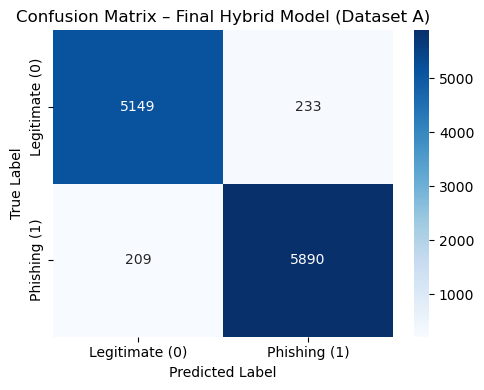

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =============================
# Confusion Matrix
# =============================
cm = confusion_matrix(y_test, ensemble_pred_A)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legitimate (0)", "Phishing (1)"],
            yticklabels=["Legitimate (0)", "Phishing (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Final Hybrid Model (Dataset A)")
plt.tight_layout()
plt.show()


In [47]:
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[5149  233]
 [ 209 5890]]


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Fit scaler on Dataset A only
scaler_A = MinMaxScaler()
X_train_A_scaled = scaler_A.fit_transform(X_train_final)
X_test_A_scaled  = scaler_A.transform(X_test_final)



Balanced Dataset C Shape: 60994
 Phishing  : 30497
 Legitimate: 30497

===== Hypothesis 3 — Dataset C =====
Accuracy           : 0.9913
Precision          : 0.9925
Recall             : 0.9900
F1-score           : 0.9913
FPR                : 0.0074
AUC-ROC            : 0.9969


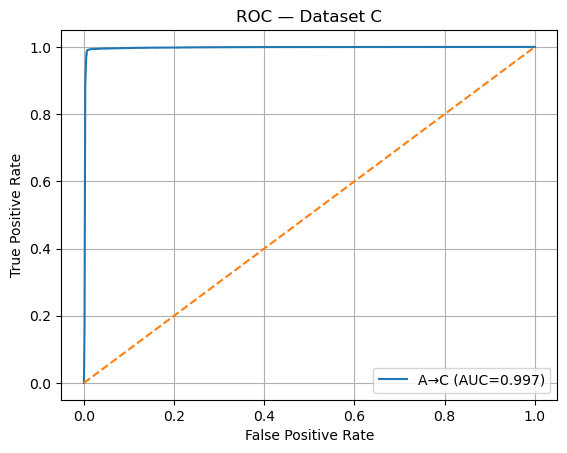

In [ ]:
# ============================================================
# HYPOTHESIS 3 — TRAIN ON DATASET A, TEST ON BALANCED DATASET B
# (with correct scaling using the SAME MinMaxScaler as Dataset A)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, balanced_accuracy_score
import matplotlib.pyplot as plt

# ============================================================
# 1. Load & clean Dataset B
# ============================================================
df_C = pd.read_csv("dataset_full.csv")
df_C = df_C.drop_duplicates()

target_col_C = "phishing"
y_C = df_C[target_col_C].to_numpy()
X_C_raw = df_C.drop(columns=[target_col_C])

# Clean Dataset B (similar style to A)
X_C_raw = X_C_raw.replace([np.inf, -np.inf], np.nan).fillna(0)

for col in X_C_raw.columns:
    if X_C_raw[col].dtype == bool:
        X_C_raw[col] = X_C_raw[col].astype(int)
    if X_C_raw[col].dtype == object:
        try:
            X_C_raw[col] = pd.to_numeric(X_C_raw[col])
        except:
            X_C_raw[col] = X_C_raw[col].factorize()[0]

# ============================================================
# 2. Align B columns to A's pre-scaled features and apply SAME scaler
#    - scaler is the MinMaxScaler() you fitted on X_train earlier
#    - X_train.columns = features used when fitting scaler
# ============================================================
# all features that scaler expects (after ISO + variance + corr removal)
all_A_features = list(X_train.columns)

# Build an aligned frame for B with those columns
X_C_align = pd.DataFrame(0, index=X_C_raw.index, columns=all_A_features)
for col in all_A_features:
    if col in X_C_raw.columns:
        X_C_align[col] = X_C_raw[col]

# Apply THE SAME scaler as Dataset A
# (important: use 'scaler' from your earlier preprocessing, do NOT refit)
X_C_scaled_full = scaler.transform(X_C_align)
X_C_scaled_full = pd.DataFrame(X_C_scaled_full, columns=all_A_features)

# Now select the final features (same as X_train_final)
selected_A_features = list(X_train_final.columns)
X_C_for_A = X_C_scaled_full[selected_A_features].copy()

# CNN input shape
X_C_tab = X_C_for_A.to_numpy().astype(np.float32)
X_C_cnn = X_C_tab.reshape(-1, X_C_tab.shape[1], 1)

# ============================================================
# 3. Balanced Subset Creation (FAIRNESS)
# ============================================================
def make_balanced_subset(y, random_state=42):
    y = np.asarray(y)
    idx_pos = np.where(y == 1)[0]  # phishing
    idx_neg = np.where(y == 0)[0]  # legitimate

    n_min = min(len(idx_pos), len(idx_neg))
    rng = np.random.RandomState(random_state)

    sel_pos = idx_pos
    sel_neg = rng.choice(idx_neg, n_min, replace=False)

    fair_idx = np.concatenate([sel_pos, sel_neg])
    rng.shuffle(fair_idx)
    return fair_idx

fair_idx = make_balanced_subset(y_C, random_state=42)

y_C_fair          = y_C[fair_idx]
X_C_cnn_fair      = X_C_cnn[fair_idx]
X_C_for_A_fair    = X_C_for_A.iloc[fair_idx]

print("\nBalanced Dataset C Shape:", len(y_C_fair))
print(" Phishing  :", np.sum(y_C_fair == 1))
print(" Legitimate:", np.sum(y_C_fair == 0))

# ============================================================
# 4. Base Predictions (from A-trained models, NO retraining)
# ============================================================
cnn_proba_C = final_cnn.predict(X_C_cnn_fair, verbose=0).flatten()
xgb_proba_C = cal_xgb.predict_proba(X_C_for_A_fair)[:, 1]

# ============================================================
# 5. Build Meta-Features + Meta-MLP Predictions
# ============================================================
_, meta_input_C = build_meta_features(
    cnn_proba_train, xgb_proba_train,   # train side (A)
    cnn_proba_C,    xgb_proba_C         # test side (balanced B)
)

proba_1_C = meta_model_1.predict(meta_input_C, verbose=0).flatten()
proba_2_C = meta_model_2.predict(meta_input_C, verbose=0).flatten()

ensemble_proba_C = best_w1 * proba_1_C + best_w2 * proba_2_C
y_pred_C = (ensemble_proba_C >= 0.5).astype(int)  # or use your optimal_threshold if defined

# ============================================================
# 6. Evaluate (Balanced Dataset B Only)
# ============================================================
accC, precC, recC, f1C, fprC, aucC = metrics_from_preds(
    y_C_fair, y_pred_C, ensemble_proba_C
)

bal_acc = balanced_accuracy_score(y_C_fair, y_pred_C)

print("\n===== Hypothesis 3 — Dataset C =====")
print(f"Accuracy           : {accC:.4f}")
print(f"Precision          : {precC:.4f}")
print(f"Recall             : {recC:.4f}")
print(f"F1-score           : {f1C:.4f}")
print(f"FPR                : {fprC:.4f}")
print(f"AUC-ROC            : {aucC:.4f}")

# ============================================================
# ROC Curve (Balanced B)
# ============================================================
fpr_c, tpr_c, _ = roc_curve(y_C_fair, ensemble_proba_C)

plt.figure()
plt.plot(fpr_c, tpr_c, label=f'A→C (AUC={aucC:.3f})')
plt.plot([0,1],[0,1],'--')
plt.title("ROC — Dataset C")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()



Confusion Matrix (A → C):
[[30270   227]
 [  305 30192]]
TN: 30270, FP: 227, FN: 305, TP: 30192


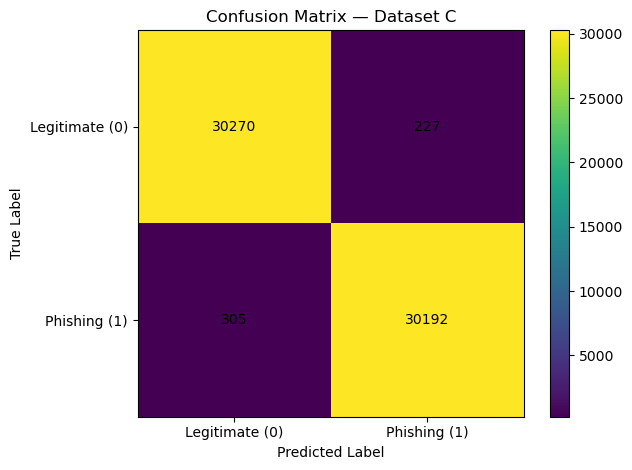

In [ ]:
from sklearn.metrics import confusion_matrix

# ============================================================
# Confusion Matrix (Balanced Dataset C)
# ============================================================
cm = confusion_matrix(y_C_fair, y_pred_C)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix (A → C):")
print(cm)
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix — Dataset C")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Legitimate (0)", "Phishing (1)"])
plt.yticks([0, 1], ["Legitimate (0)", "Phishing (1)"])

# Annotate counts in each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()


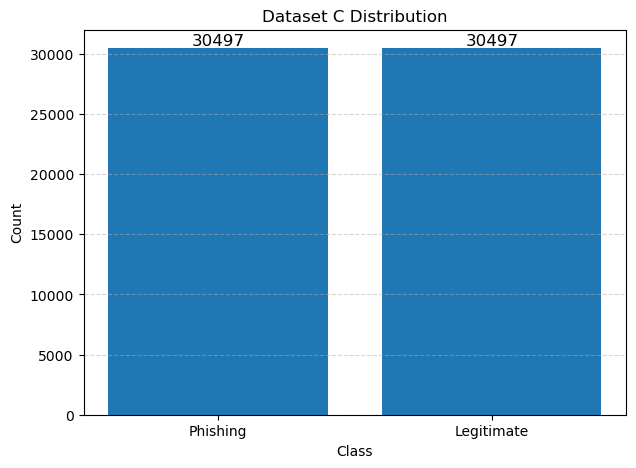

In [209]:
import matplotlib.pyplot as plt
import numpy as np

# Compute counts
counts = [
    np.sum(y_C_fair == 1),   # phishing
    np.sum(y_C_fair == 0)    # legitimate
]

labels = ["Phishing", "Legitimate"]

# Plot
plt.figure(figsize=(7,5))
bars = plt.bar(labels, counts)

plt.title("Dataset C Distribution")
plt.ylabel("Count")
plt.xlabel("Class")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# ---- Add value labels on top of bars ----
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(height),
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.show()


In [201]:
print("\n=== Final Features Used in Dataset A (X_train_final) ===")
print(list(X_train_final.columns))
print("Total features:", len(X_train_final.columns))



=== Final Features Used in Dataset A (X_train_final) ===
['directory_length', 'length_url', 'time_domain_activation', 'qty_slash_url', 'file_length', 'ttl_hostname', 'asn_ip', 'qty_dot_directory', 'qty_dot_domain', 'time_domain_expiration', 'qty_hyphen_file', 'qty_hyphen_directory', 'qty_underline_directory', 'qty_equal_directory', 'time_response', 'qty_vowels_domain', 'qty_dot_url', 'qty_mx_servers', 'params_length', 'qty_ip_resolved', 'qty_nameservers', 'qty_hyphen_url', 'qty_redirects', 'qty_hyphen_params', 'tls_ssl_certificate', 'domain_spf', 'qty_equal_url', 'qty_slash_params', 'qty_percent_params', 'qty_questionmark_params']
Total features: 30


In [202]:
print("\n=== Features Extracted for Dataset B (X_C_for_A) ===")
print(list(X_C_for_A.columns))
print("Total features:", len(X_C_for_A.columns))



=== Features Extracted for Dataset B (X_C_for_A) ===
['directory_length', 'length_url', 'time_domain_activation', 'qty_slash_url', 'file_length', 'ttl_hostname', 'asn_ip', 'qty_dot_directory', 'qty_dot_domain', 'time_domain_expiration', 'qty_hyphen_file', 'qty_hyphen_directory', 'qty_underline_directory', 'qty_equal_directory', 'time_response', 'qty_vowels_domain', 'qty_dot_url', 'qty_mx_servers', 'params_length', 'qty_ip_resolved', 'qty_nameservers', 'qty_hyphen_url', 'qty_redirects', 'qty_hyphen_params', 'tls_ssl_certificate', 'domain_spf', 'qty_equal_url', 'qty_slash_params', 'qty_percent_params', 'qty_questionmark_params']
Total features: 30


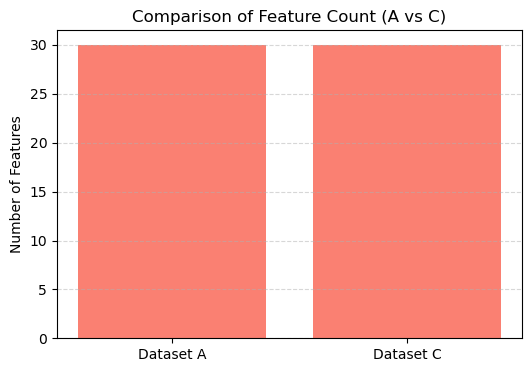

In [211]:
plt.figure(figsize=(6,4))
plt.bar(
    ["Dataset A", "Dataset C"],
    [len(X_train_final.columns), len(X_C_for_A.columns)],
    color=["#FA8072", "#FA8072"]   # salmon color
   # blue, orange
)

plt.title("Comparison of Feature Count (A vs C)")
plt.ylabel("Number of Features")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [206]:
import pandas as pd

features_A = list(X_train_final.columns)
features_B = list(X_C_for_A.columns)

comparison_df = pd.DataFrame({
    "Dataset A Features": features_A,
    "Dataset B Features (Aligned)": features_B
})

comparison_df


,Dataset A Features,Dataset B Features (Aligned)
0,directory_length,directory_length
1,length_url,length_url
2,time_domain_activation,time_domain_activation
3,qty_slash_url,qty_slash_url
4,file_length,file_length
5,ttl_hostname,ttl_hostname
6,asn_ip,asn_ip
7,qty_dot_directory,qty_dot_directory
8,qty_dot_domain,qty_dot_domain
9,time_domain_expiration,time_domain_expiration


In [190]:
import numpy as np
from sklearn.metrics import f1_score, recall_score, roc_auc_score

def bootstrap_test(metric_fn, y_a, p_a, y_b, p_b, n_bootstrap=5000):
    diffs = []
    n_a = len(y_a)
    n_b = len(y_b)

    for _ in range(n_bootstrap):
        # sample with replacement
        idx_a = np.random.choice(n_a, n_a, replace=True)
        idx_b = np.random.choice(n_b, n_b, replace=True)

        # compute metric on both datasets
        m_a = metric_fn(y_a[idx_a], p_a[idx_a])
        m_b = metric_fn(y_b[idx_b], p_b[idx_b])

        diffs.append(m_a - m_b)

    diffs = np.array(diffs)
    lower = np.percentile(diffs, 2.5)
    upper = np.percentile(diffs, 97.5)
    mean_diff = np.mean(diffs)

    return mean_diff, (lower, upper)


# ======================================================
# CHOOSE A METRIC FOR TESTING
# ======================================================

# 1. AUC-based test (best choice)
auc_metric = lambda y, p: roc_auc_score(y, p)

auc_diff, auc_ci = bootstrap_test(
    auc_metric,
    y_test.to_numpy(), ensemble_proba_A,
    y_C_fair, ensemble_proba_C
)

print("\n=== Bootstrap Test (AUC) ===")
print("Mean Difference (A - B):", auc_diff)
print("95% CI:", auc_ci)

f1_metric = lambda y, p: f1_score(y, (p >= 0.5).astype(int))
recall_metric = lambda y, p: recall_score(y, (p >= 0.5).astype(int))

f1_diff, f1_ci = bootstrap_test(
    f1_metric, 
    y_test.to_numpy(), ensemble_proba_A,
    y_C_fair, ensemble_proba_C
)

recall_diff, recall_ci = bootstrap_test(
    recall_metric, 
    y_test.to_numpy(), ensemble_proba_A,
    y_C_fair, ensemble_proba_C
)

print("\n=== Bootstrap Test (F1) ===")
print("Mean Difference (A - B):", f1_diff)
print("95% CI:", f1_ci)

print("\n=== Bootstrap Test (Recall) ===")
print("Mean Difference (A - B):", recall_diff)
print("95% CI:", recall_ci)



=== Bootstrap Test (AUC) ===
Mean Difference (A - B): -0.02652254277120129
95% CI: (-0.030749736040032442, -0.022610389561541357)

=== Bootstrap Test (F1) ===
Mean Difference (A - B): -0.027635453169329735
95% CI: (-0.03116560559682112, -0.024283386568276392)

=== Bootstrap Test (Recall) ===
Mean Difference (A - B): -0.02664173162393647
95% CI: (-0.031425071143014335, -0.021822389284712376)


In [215]:
print("   Bootstrap Significance Test (5000 Resamples): A vs C Performance Difference")

# Assemble bootstrap results into a DataFrame
bootstrap_df = pd.DataFrame({
    "Metric": ["AUC-ROC", "F1-score", "Recall"],
    "Mean Difference (A - C)": [auc_diff, f1_diff, recall_diff],
    "95% CI Lower": [auc_ci[0], f1_ci[0], recall_ci[0]],
    "95% CI Upper": [auc_ci[1], f1_ci[1], recall_ci[1]]
})

def interpret(diff, ci):
    if ci[0] > 0:
        return "A significantly better"
    elif ci[1] < 0:
        return "C significantly better"
    else:
        return "No significant difference"

bootstrap_df["Interpretation"] = [
    interpret(auc_diff, auc_ci),
    interpret(f1_diff, f1_ci),
    interpret(recall_diff, recall_ci)
]

bootstrap_df


   Bootstrap Significance Test (5000 Resamples): A vs C Performance Difference


,Metric,Mean Difference (A - C),95% CI Lower,95% CI Upper,Interpretation
0,AUC-ROC,-0.026523,-0.030750,-0.022610,C significantly better
1,F1-score,-0.027635,-0.031166,-0.024283,C significantly better
2,Recall,-0.026642,-0.031425,-0.021822,C significantly better
